# 📥 Part 1: Data Preprocessing
Steps:
- Load `ecommerce_user_data.csv` and `product_details.csv` ✅
- Merge data if necessary ✅
- Create user-item matrix ✅
- Fill missing ratings with 0 ✅
- Group user behavior by category ✅

## Loading Data

In [ ]:
# Load data
import pandas as pd

user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

# Visualize a couple rows to see what our data looks like
print("User Data\n---------------\n",user_data.head())
print("\nProduct Details\n---------------\n", product_data.head())

User Data
---------------
   UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys

Product Details
---------------
   ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


We see that the User Data contains "ProductID" as a column, which is the unique identifier in the Product Details dataset, so we can later do a merge using this column.

## Data Cleaning

In [ ]:
# Check for duplicates in both datasets
print("User Data Duplicates:", user_data.duplicated().sum())
print("Product Details Duplicates:", product_data.duplicated().sum())

User Data Duplicates: 0
Product Details Duplicates: 0


There are no duplicates, so we do not need to worry about dropping any rows.

In [ ]:
# Check missing data in both datasets
print("User Data\n---------------\n", user_data.isnull().sum())
print("\nProduct Details\n---------------\n", product_data.isnull().sum())

User Data
---------------
 UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64

Product Details
---------------
 ProductID      0
ProductName    0
Category       0
dtype: int64


We see that our original sets do not have missing values, so we also do not need to concern ourselves with any imputation here.

## Data Merging

In [ ]:
# We now merge both datasets
merged_data = pd.merge(user_data, product_data, on = 'ProductID')
merged_data.head()

,UserID,ProductID,Rating,Timestamp,Category_x,ProductName,Category_y
0,U000,P0009,5,2024-09-08,Books,Clothing Item 9,Books
1,U000,P0020,1,2024-09-02,Home,Clothing Item 20,Home
2,U000,P0012,4,2024-10-18,Books,Beauty Item 12,Books
3,U000,P0013,1,2024-09-18,Clothing,Clothing Item 13,Clothing
4,U000,P0070,4,2024-09-16,Toys,Beauty Item 70,Toys


Note that the reason for merging datasets is to faciliate later steps by having all information be in one DataFrame (this way we won't have to do multiple joins later on).

We notice that because both datasets had a "Category" column, we now have two times the same column. We'll first verify that the cells in "Category_x" and "Category_y" match for every row.

In [ ]:
different_categories = merged_data[merged_data['Category_x'] != merged_data['Category_y']]

# Display mismatched rows
different_categories

,UserID,ProductID,Rating,Timestamp,Category_x,ProductName,Category_y


Good, since no row is appearing, we can understand that every row is consistent for both columns, so we know that we can safely drop one of the two columns.

In [ ]:
# First drop the Category_x column
merged_data.drop(columns = ['Category_x'], inplace=True)

# Then rename Category_y to Category to make it cleaner
merged_data.rename(columns = {'Category_y': 'Category'}, inplace = True)

# And lastly, visualize the result
merged_data.head()

,UserID,ProductID,Rating,Timestamp,ProductName,Category
0,U000,P0009,5,2024-09-08,Clothing Item 9,Books
1,U000,P0020,1,2024-09-02,Clothing Item 20,Home
2,U000,P0012,4,2024-10-18,Beauty Item 12,Books
3,U000,P0013,1,2024-09-18,Clothing Item 13,Clothing
4,U000,P0070,4,2024-09-16,Beauty Item 70,Toys


Now that we have our clean, merged data set, we can proceed to created the user-item matrix.

## User-Item Matrix

In [ ]:
# Create user-item matrix from the merged data and check for missing ratings
user_item_matrix = merged_data.pivot_table(index = 'UserID', columns = 'ProductID', values = 'Rating')
user_item_matrix.head()

ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,NaN,NaN,NaN,3.0,NaN,5.0,NaN,3.0,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
U001,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
U002,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
U003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
U004,NaN,3.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,4.0,3.0


We see that there are indeed a lot of missing ratings (which makes sense), so we will be imputing these missing values by replacing them with 0. But first, we verify how many missing ratings we have (because we will need that information later for metrics).

In [ ]:
# Count number of cells that are null
# First sum counts the number of nulls per product
# Second sum sums up all the values together
nulls = user_item_matrix.isnull().sum().sum()
print("Number of missing ratings:", nulls)

# Count number of cells in the matrix
cells = user_item_matrix.size
print("Total number of cells in the matrix:", cells)

Number of missing ratings: 4276
Total number of cells in the matrix: 5000


We see that we have a lot of missing values. Again, we will rediscuss this in the metrics section.

In [ ]:
# Fill missing values of matrix with 0
user_item_matrix_filled = user_item_matrix.fillna(0)
user_item_matrix_filled.head()

ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


Good. We can now move on to aggregation.

## Aggregation

In [ ]:
# Aggregate user behavior by category
user_category_agg = merged_data.groupby(['UserID', 'Category']).agg({'Rating': ['count', 'mean']}).reset_index()
user_category_agg.columns = ['UserID', 'Category', 'TotalInteractions', 'AverageRating']
# We set the head to a bigger value to ensure that the aggregation worked for more than
# just the first user
user_category_agg.head(100)

,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.666667
1,U000,Clothing,3,1.666667
2,U000,Electronics,3,3.666667
3,U000,Home,2,1.000000
4,U000,Toys,6,3.500000
...,...,...,...,...
95,U017,Books,4,4.250000
96,U017,Clothing,3,3.000000
97,U017,Electronics,3,3.333333
98,U017,Home,2,4.500000


# 🤝 Part 2: User-Based Collaborative Filtering
Steps:
- Use cosine similarity to compare users ✅
- Recommend top-N products based on similar users ✅
- Evaluate with Precision@K and Coverage ✅

## Cosine Similarity

In [ ]:
# Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

# First compute the similarity matrix using Cosine similarity
similarity_matrix = cosine_similarity(user_item_matrix_filled)

# Then convert the matrix to a dataframe
similarity_df = pd.DataFrame(similarity_matrix, index = user_item_matrix_filled.index,
                             columns = user_item_matrix_filled.index)
similarity_df.head()

UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412,0.161251,0.160096,0.092083,0.238263,0.274844,...,0.241693,0.129483,0.156790,0.132200,0.161478,0.100346,0.126917,0.150727,0.000000,0.104294
U001,0.063071,1.000000,0.190861,0.000000,0.111332,0.009540,0.000000,0.172286,0.167460,0.017593,...,0.121540,0.024075,0.097953,0.007821,0.000000,0.000000,0.193670,0.247805,0.000000,0.000000
U002,0.195522,0.190861,1.000000,0.065094,0.111662,0.050830,0.027756,0.055877,0.000000,0.181229,...,0.144756,0.000000,0.217465,0.000000,0.055992,0.034794,0.194243,0.110030,0.177165,0.000000
U003,0.023466,0.000000,0.065094,1.000000,0.035737,0.104116,0.026650,0.000000,0.025384,0.288009,...,0.243836,0.000000,0.000000,0.074688,0.197121,0.000000,0.054396,0.126773,0.374228,0.250000
U004,0.065412,0.111332,0.111662,0.035737,1.000000,0.159064,0.057144,0.026294,0.195942,0.247023,...,0.062741,0.116202,0.078797,0.048044,0.103747,0.133716,0.124969,0.217464,0.255318,0.172729


We can see that diagonals are all equal to 1, which makes sense because it's comparing a user 'x' to themselves, so it's obviously going to be a perfect match. Then, the off-diagonal values vary more, with some users being more similar than others.

## Recommendation Function

In [ ]:
import numpy as np
# Create recommendation function
# Find most similar user, recommend products they rated highly that target user
# hasn’t rated
# Parameters:
# - user_id -> the target user we want to make recommendations to
# - num_users -> the number of similar users that we're looking at
#                  (default = 5)
# - num_recommendations -> the number of products recommended we should return.
#                         (default = 5)
def recommend_products(user_id, num_users = 5, num_recommendations = 5):
    # Use the similarity_df to sort users by most similar
    similar_users = similarity_df[user_id].sort_values(ascending = False)

    # Then get the top 'n' users, skipping the top one (which is target user)
    top_similar_users = similar_users.iloc[1 : num_users + 1]

    # Optimization: apply min-max scaling to normalize similarity scores to [0,1]
    # First find the min and max similarities
    min_sim = top_similar_users.min()
    max_sim = top_similar_users.max()

    # Then apply the Min-Max scaling formula
    # We add a small value (1e-8) to ensure we won't divide by 0
    top_similar_users = (top_similar_users - min_sim) / (max_sim - min_sim + 1e-8)

    # Optimization: apply power to the similar users to emphasize more similar users
    # even more
    top_similar_users = np.power(top_similar_users, 2)

    # Now that our top_similar_users are ready, get the ratings of those top
    # similar users
    top_users_ratings = user_item_matrix_filled.loc[top_similar_users.index]

    # # Optimization: Min-max scaling 2
    # This is our last optimization, where we give more weight to users that have
    # rated more items
    num_ratings_per_user = (top_users_ratings > 0).sum(axis=1)

    # Since the min of ratings = 0, we do not need to include the value in the formula
    confidence = num_ratings_per_user / num_ratings_per_user.max()

    # Apply the weighing to our top users
    top_similar_users = top_similar_users * confidence

    # Now, we'll use the Weighted Sum Using Similarity Scores formula to ensure that
    # more similar users have more impact on the recommendations
    # We'll first apply the formula to every item

    # First compute the numerators
    numerators = top_users_ratings.mul(top_similar_users, axis = 0).sum(axis = 0)

    # Then compute the denominator (it's the same for all items)
    denominator = top_similar_users.sum()

    # Lastly, compute the weighted sum for each of the items
    weighted_sums = numerators / denominator

    # We'll then retrieve the items rated by our target user to make sure not to
    # include those
    rated_by_target = user_item_matrix_filled.loc[user_id]

    # Get the top 'm' items, where the target user's rating is "0"
    top_items = weighted_sums[rated_by_target == 0].sort_values(ascending =
                    False).head(num_recommendations)

    return top_items

# Test the function, using user 'U000' and default parameters
recommended_products1 = recommend_products('U000')
recommended_products1

,0
ProductID,
P0051,4.594846
P0029,4.163446
P0064,4.163446
P0058,3.411047
P0052,3.037318


We retrieve the 5 best-fitting items based on the 5 users that U001 is most similar to (the table shows us the product ID and the predicted rating score).

In [ ]:
# Testing the function this time with custom parameters
recommended_products2 = recommend_products('U000', num_users = 8, num_recommendations = 10)
recommended_products2

,0
ProductID,
P0051,4.339938
P0064,3.826735
P0029,3.815680
P0058,3.194704
P0052,2.965689
P0060,2.440579
P0001,2.305145
P0066,1.526326
P0083,0.892232


Now that we know the function works, we can evaluate it.

## Evaluation Metrics

We start with Precision@K (how many recommended items are actually relevant from the 'K' ones) and Recall@K (how many of the relevant items were actually recommended).

However, the issue here is that these two metrics require for recommended items to possibly include items that the target user has already rated.

So, we'll slightly modify our original function to remove only the part where we
exclude items rated by our target user.


In [ ]:
import numpy as np

def recommend_products2(user_id, num_users = 5, num_recommendations = 5):
    # Use the similarity_df to sort users by most similar
    similar_users = similarity_df[user_id].sort_values(ascending = False)

    # Then get the top 'n' users, skipping the top one (which is target user)
    top_similar_users = similar_users.iloc[1 : num_users + 1]

    # Optimization: apply min-max scaling to normalize similarity scores to [0,1]
    # First find the min and max similarities
    min_sim = top_similar_users.min()
    max_sim = top_similar_users.max()

    # Then apply the Min-Max scaling formula
    # We add a small value (1e-8) to ensure we won't divide by 0
    top_similar_users = (top_similar_users - min_sim) / (max_sim - min_sim + 1e-8)

    # Optimization: apply power to the similar users to emphasize more similar users
    # even more
    top_similar_users = np.power(top_similar_users, 2)

    # Now that our top_similar_users are ready, get the ratings of those top
    # similar users
    top_users_ratings = user_item_matrix_filled.loc[top_similar_users.index]

    # # Optimization: Min-max scaling 2
    # This is our last optimization, where we give more weight to users that have
    # rated more items
    num_ratings_per_user = (top_users_ratings > 0).sum(axis=1)

    # Since the min of ratings = 0, we do not need to include the value in the formula
    confidence = num_ratings_per_user / num_ratings_per_user.max()

    # Apply the weighing to our top users
    top_similar_users = top_similar_users * confidence

    # Now, we'll use the Weighted Sum Using Similarity Scores formula to ensure that
    # more similar users have more impact on the recommendations
    # We'll first apply the formula to every item

    # First compute the numerators
    numerators = top_users_ratings.mul(top_similar_users, axis = 0).sum(axis = 0)

    # Then compute the denominator (it's the same for all items)
    denominator = top_similar_users.sum()

    # Lastly, compute the weighted sum for each of the items
    weighted_sums = numerators / denominator

    # Get the top 'm' items, where the target user's rating is "0"
    top_items = weighted_sums.sort_values(ascending =
                    False).head(num_recommendations)

    return top_items

Now that the function is redefined, we can test the metrics. Please note that if someone were to use this system, they should use recommend_products function, not the recommend_products2 function, as there is no point to recommending items that the user has already rated.

In [ ]:
# Compute the precision@k and recall@k
# We'll compute it for every user to get an overview of how our function performs
def precision_recall_at_k(num_users = 5, num_recommendations = 5):
    # First get all the users
    users = user_item_matrix_filled.index

    # If there are no users
    if users.empty:
        return 0, 0

    # Create lists for the precisions and recalls
    precisions = []
    recalls = []

    for user_id in users:
      # First, apply the recommend_products2 function defined above to retrieve top
      # recommendations
      recommended_products = recommend_products2(user_id, num_users, num_recommendations).index

      # Retrieve the items rated by the target user that have a rating >= 4
      high_rated_items = user_item_matrix_filled.loc[user_id][user_item_matrix_filled.loc[user_id] >= 4].index

      # If the user hasn't rated anything as >= 4
      if len(high_rated_items) == 0:
          precisions.append(0)
          recalls.append(0)
          continue

      # PRECISION@K
      # First find the intersection between the recommended_products and high_rated_items
      relevant_recommendations = set(recommended_products) & set(high_rated_items)
      # Then apply the formula
      precision = len(relevant_recommendations) / num_recommendations
      precisions.append(precision)

      # RECALL@K
      # Apply the formula
      recall = len(relevant_recommendations) / len(high_rated_items)
      recalls.append(recall)

    return precisions, recalls

# Testing with values to obtain the best precision, recall:
precisions, recalls = precision_recall_at_k(5, 14)
users = user_item_matrix_filled.index

for i, user in enumerate(users):
  print(f"User {i}")
  print(f"Precision: {precisions[i]}")
  print(f"Recall: {recalls[i]}\n")
  print(f"---------------------------")

print(f"Average Precision: {np.mean(precisions):.2f}")
print(f"Average Recall: {np.mean(recalls):.2f}")

User 0
Precision: 0.42857142857142855
Recall: 0.75

---------------------------
User 1
Precision: 0.07142857142857142
Recall: 0.2

---------------------------
User 2
Precision: 0.14285714285714285
Recall: 0.4

---------------------------
User 3
Precision: 0.14285714285714285
Recall: 1.0

---------------------------
User 4
Precision: 0.14285714285714285
Recall: 0.4

---------------------------
User 5
Precision: 0.14285714285714285
Recall: 0.5

---------------------------
User 6
Precision: 0.2857142857142857
Recall: 0.5714285714285714

---------------------------
User 7
Precision: 0.14285714285714285
Recall: 0.3333333333333333

---------------------------
User 8
Precision: 0.2857142857142857
Recall: 0.6666666666666666

---------------------------
User 9
Precision: 0.14285714285714285
Recall: 0.2857142857142857

---------------------------
User 10
Precision: 0.35714285714285715
Recall: 0.5

---------------------------
User 11
Precision: 0.21428571428571427
Recall: 0.3333333333333333

----

We see that the recall@k is oftentimes at an acceptable level, probably because we are returning many recommendations, but the precision@k is fairly low, despite having implemented many optimization techniques. There are multiple reasons for why this is happening:
<br><br>
1) We are working with extremely sparse data. Out of 5000 cells (in our user-item matrix) 4276 were empty. <br>
2) Our dataset is relatively small, with only 50 users and 100 items.
<br><br>
We will now be proceeding to the MAP metric, keeping in mind that its results will most likely not be very performant, considering it uses precision@k, which we just found ot be relatively low.

In [ ]:
# To compute the Mean Average Precision (MAP), we first need the average precision
# per user
def average_precision_per_user(user_id, num_users = 5, num_recommendations = 5):
    # If no recommendations were returned, directly return 0, 0
    if num_recommendations == 0:
        return 0

    # First, apply the recommend_products2 function defined above to retrieve top
    # recommenadtions
    recommended_products = recommend_products2(user_id, num_users, num_recommendations).index

    # Retrieve the items rated by the target user that have a rating >= 4
    high_rated_items = user_item_matrix_filled.loc[user_id][user_item_matrix_filled.loc[user_id] >= 4].index

    # If the user hasn't rated anything as >= 4
    if len(high_rated_items) == 0:
        return 0

    # Next, we need to compute the Precision@i, where i increases by 1 after each iteration
    # Reminder: Precision@K = # of relevant recommendations) / num_recommendations
    cummulative_precision_at_i = 0
    num_relevant = 0

    # So we iterate through the recommended products
    for i, item in enumerate(recommended_products):
        # If the item is also part of high_rated_items, we increase num_relevant
        # by 1, and update cummulative_precision_at_i
        if item in high_rated_items:
            num_relevant += 1
            # i + 1, because i starts at 0
            cummulative_precision_at_i += num_relevant / (i + 1)

    # Lastly, return the average precision using its formula
    return cummulative_precision_at_i / len(high_rated_items)

Now, we can compute MAP.

In [ ]:
# Compute Mean Average Precision (MAP) using function defined above
def mean_average_precision(num_users = 5, num_recommendations = 5):
  # Retrieve list of users
  users = user_item_matrix_filled.index

  # If there are none, return 0
  if users.empty:
    return 0

  # This is where we'll cummulate the precision per user
  total_precision = 0

  # For each user, calculate the AP, and increase total_precision
  for user in users:
    precision = average_precision_per_user(user, num_users = num_users,
                                  num_recommendations = num_recommendations)
    total_precision += precision

  # Return the mean average precision
  return total_precision / len(users)

# Testing with the same values as above:
map = mean_average_precision(num_users = 5, num_recommendations = 14)
print(f"Mean Average Precision: {map:.2f}")

Mean Average Precision: 0.30


As expected, the MAP is very low. This makes complete sense with the metrics that we previously found. Since our dataset is not very informative, we can not expect to obtain a high mean average precision.

We'll now move on to the coverage metric.

In [ ]:
# Coverage: checking how well our recommender system can recommend all items to users
def coverage():
    # Retrieve list of users
    users = user_item_matrix_filled.index

    # If there are none, return 0
    if users.empty:
        return 0

    # Create a set to keep track of the unique recommendations made for the users
    all_recommendations = set()

    # Now iterate through the users and apply the recommendation function
    # Here, we use the initial recommend_products function, since we don't want to
    # recommend items already rated by the users
    # We'll use the default parameters
    for user in users:
        recommended_products = recommend_products(user).index
        all_recommendations.update(recommended_products)

    return len(all_recommendations) / len(user_item_matrix_filled.columns)

# Test it
coverage_score = coverage()
print(f"Coverage: {coverage_score:.2f}")

Coverage: 0.87


So, although our recommender system has poor precision, it actually has very good coverage. A value of 87% means that 87% of items from the dataset have been recommended to at least one user.

The last metric we would like to verify is Diversity.

In [ ]:
from sklearn.metrics import jaccard_score
from itertools import combinations

# Diversity: how different the recommendations are from one user to another
def diversity():
    # Retrieve list of users
    users = user_item_matrix_filled.index

    # If there are none, return 0
    if users.empty:
        return

    # First, get the top recommendations for each user
    # Similarly to Coverage, we'll be using the first recommended_products function
    # using default parameters
    top_recommendations = {}
    for user in users:
      # Use set to remove possible duplicates
      top_recommendations[user] = set(recommend_products(user).index)

    # Then, create a list of all recommended items
    # Unionize the values from each set in top_recommendations.values()
    all_recommendations = set.union(set(), *top_recommendations.values())

    # Next, convert the recommendations (all_recommendations) to binary for each user
    # Basically, if that item was recommended to the user, put a value "1", otherwise, put "0"
    binary_recommendations = {}
    for user in users:
      binary_recommendations[user] = [1 if item in top_recommendations[user] else 0 for item in all_recommendations]

    # Convert the keys of the dictionary to a list so we can use indexing for the users
    user_list = list(binary_recommendations.keys())

    # And this is where we'll store the similarity scores
    similiarties = []

    # Now, we compute the Jaccard similarity for every pair of users possible
    for user1, user2 in combinations(user_list, 2):
      similarity = jaccard_score(binary_recommendations[user1], binary_recommendations[user2])
      similiarties.append(similarity)

    # Lastly, compute divserity using the formula
    return 1 - np.mean(similiarties)

# Test it
diversity_score = diversity()
print(f"Diversity: {diversity_score:.2f}")

Diversity: 0.96


This is the best metric we've obtained so far. This tells us that the recommendations made to various users are different from one another, indicating the the recommendation system is not generalizing for every one, it is making personalized recommendations.

## 🔍 Part 3: Association Rule Mining (Apriori)
Steps:
- Convert user-product interactions to transaction format
- Apply Apriori algorithm to find frequent itemsets
- Generate association rules (support, confidence, lift)

In [ ]:
# Convert to transaction format
from mlxtend.preprocessing import TransactionEncoder
transactions = user_data.groupby('UserID')['ProductID'].apply(list).tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
print(df_trans.head())

   P0000  P0001  P0002  P0003  P0004  P0005  P0006  P0007  P0008  P0009  ...  \
0  False  False  False   True  False   True  False   True  False   True  ...   
1  False  False   True  False  False  False  False  False  False  False  ...   
2  False  False  False  False  False   True  False  False  False  False  ...   
3  False  False  False  False  False  False  False  False  False  False  ...   
4  False   True  False  False  False  False   True  False  False  False  ...   

   P0090  P0091  P0092  P0093  P0094  P0095  P0096  P0097  P0098  P0099  
0  False  False  False  False  False  False  False  False  False  False  
1  False   True  False  False  False   True  False  False  False  False  
2  False  False  False  False  False  False  False  False  False  False  
3  False  False  False  False  False  False  False   True  False  False  
4  False  False   True  False  False  False  False  False   True   True  

[5 rows x 100 columns]


Now let's use the apriori algorithm.

In [ ]:
# Apply Apriori and generate rules
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,(P0000),(P0008),0.06,0.500000,2.777778
1,(P0000),(P0023),0.06,0.500000,3.125000
2,(P0000),(P0030),0.06,0.500000,2.272727
3,(P0000),(P0071),0.06,0.500000,2.777778
4,(P0091),(P0001),0.08,0.571429,3.174603


Let's first get some information on the number of frequent itemsets found and the number of association rules found.

In [ ]:
print('Number of frequent itemsets found: ' , frequent_itemsets.shape[0])
print('Number of association rules found: ' , rules.shape[0])

Number of frequent itemsets found:  612
Number of association rules found:  527


Now let's see the distribution of the number of items in each itemset.

In [ ]:
# Count the number of itemsets for each number of items in the itemset
itemset_sizes = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Get the count of itemsets for each size
itemset_size_counts = itemset_sizes.value_counts().sort_index()

print(itemset_size_counts)

itemsets
1     99
2    428
3     75
4      9
5      1
Name: count, dtype: int64


## 📊 Part 4: Visualization
Steps:
- Plot user similarity heatmap
- Plot top frequent itemsets
- Visualize top recommendations

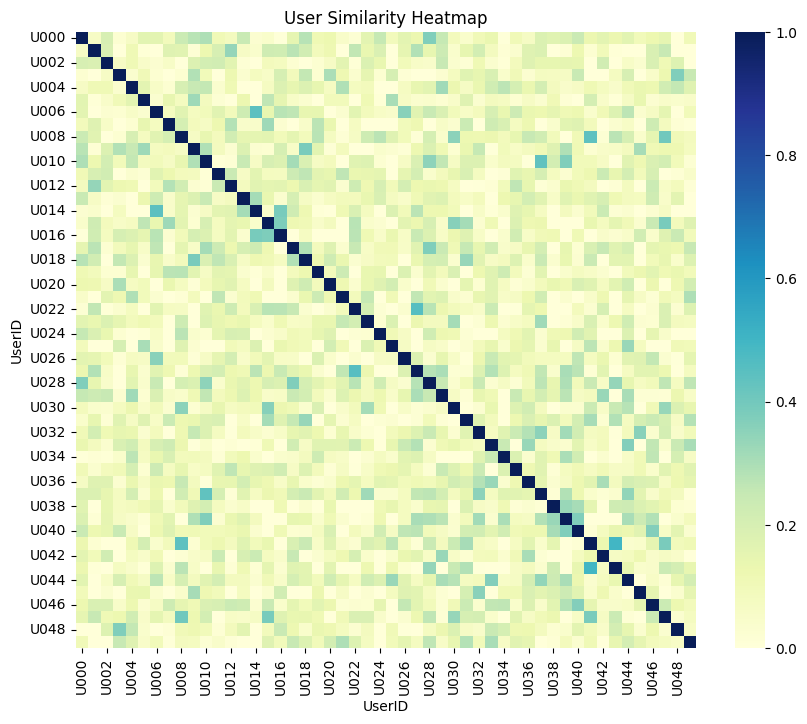

In [ ]:
# Heatmap of user similarity
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, cmap='YlGnBu')
plt.title('User Similarity Heatmap')
plt.show()

This is

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Load user-item interaction data
user_item_matrix = user_data.pivot(index='UserID', columns='ProductID', values='Rating').fillna(0)

# Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_matrix)
similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# Get top N recommended products for each user
def get_top_n_recommendations(user_id, n=5):
    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:6]  # Exclude self
    similar_users_list = similar_users.index.tolist()

    recommended_products = user_data[user_data['UserID'].isin(similar_users_list)]
    recommended_products = recommended_products.groupby('ProductID')['Rating'].sum().sort_values(ascending=False)

    return recommended_products.head(n).index.tolist()

# Assign users to groups
num_groups = 5
user_groups = {user: i % num_groups for i, user in enumerate(user_item_matrix.index)}

# Generate top 5 recommendations per user group
group_recommendations = {}
for group_id in range(num_groups):
    group_users = [user for user, group in user_groups.items() if group == group_id]
    all_recommended = []

    for user in group_users:
        all_recommended.extend(get_top_n_recommendations(user, 5))

    # Get most frequently recommended products
    group_recommendations[group_id] = pd.Series(all_recommended).value_counts().index[:5].tolist()

# Print results
for group, products in group_recommendations.items():
    print(f'Group {group}: {products}')


Group 0: ['P0070', 'P0088', 'P0077', 'P0089', 'P0060']
Group 1: ['P0039', 'P0015', 'P0094', 'P0064', 'P0016']
Group 2: ['P0070', 'P0051', 'P0030', 'P0088', 'P0064']
Group 3: ['P0070', 'P0060', 'P0094', 'P0044', 'P0088']
Group 4: ['P0070', 'P0077', 'P0043', 'P0041', 'P0008']


Now let's try and visualize some of our results for the apriori algorithm. First we want to see how frequent the most frequent itemsets were. Since the itemsets with less items are logically more frequent, we then restricted the graphs to itemsets with more than x items.

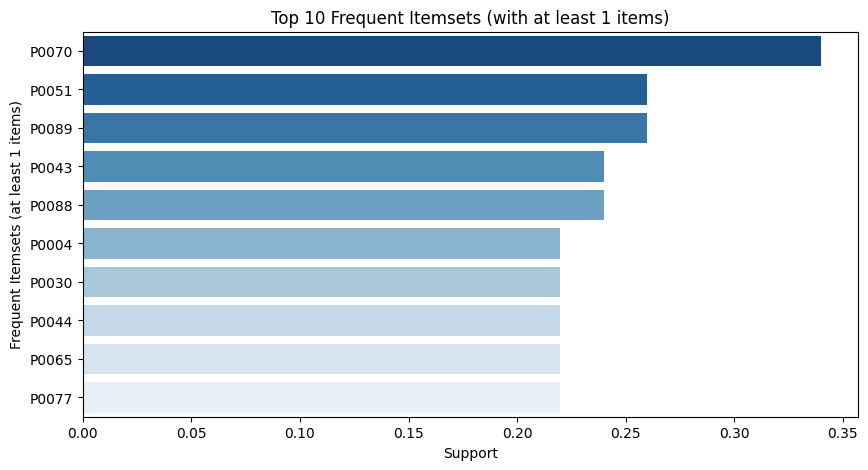

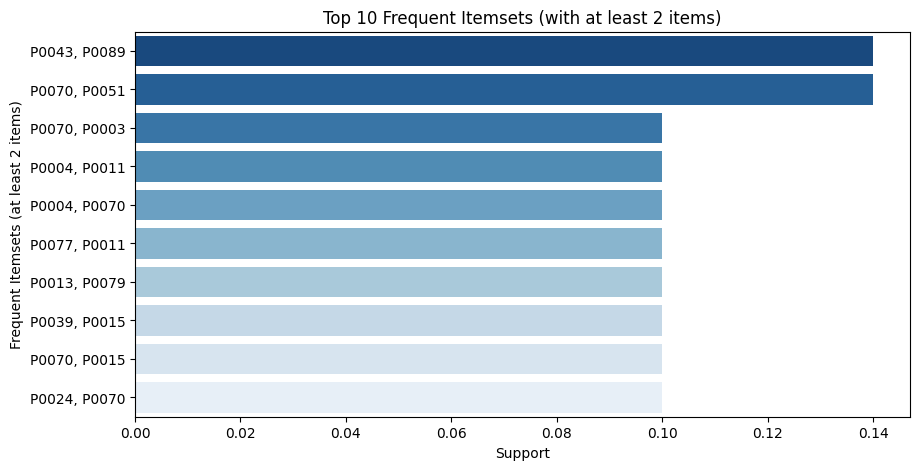

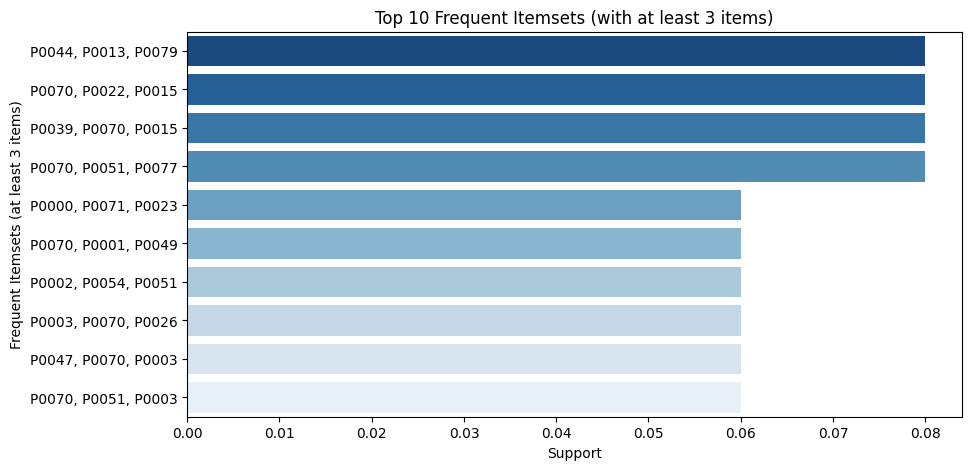

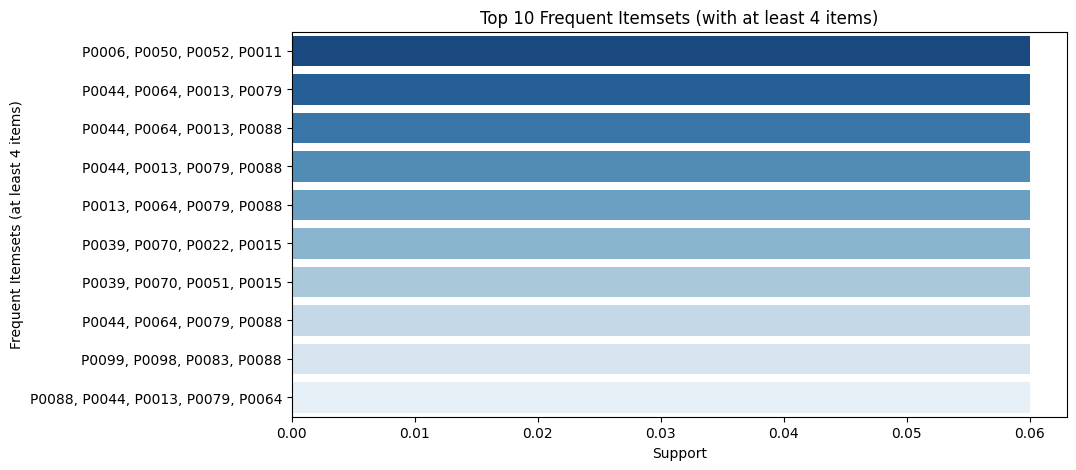

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to filter itemsets based on size and plot the graph
def plot_frequent_itemsets(itemsets, min_items=1, top_n=10):
    # Filter itemsets to include only those with at least 'min_items' items
    filtered_itemsets = itemsets[itemsets['itemsets'].apply(lambda x: len(x) >= min_items)]

    # Sort itemsets by support and select the top 'top_n'
    top_itemsets = filtered_itemsets.nlargest(top_n, 'support').copy()

    # Convert frozenset to string for visualization
    top_itemsets['itemsets'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

    # Plot the bar chart
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_itemsets, x='support', y='itemsets', hue='itemsets', palette='Blues_r', legend=False)
    plt.xlabel('Support')
    plt.ylabel(f'Frequent Itemsets (at least {min_items} items)')
    plt.title(f'Top {top_n} Frequent Itemsets (with at least {min_items} items)')
    plt.show()

# Plot the graphs for different itemset sizes
plot_frequent_itemsets(frequent_itemsets, min_items=1, top_n=10)  # 1 item
plot_frequent_itemsets(frequent_itemsets, min_items=2, top_n=10)  # More than 1 item
plot_frequent_itemsets(frequent_itemsets, min_items=3, top_n=10)  # More than 2 items
plot_frequent_itemsets(frequent_itemsets, min_items=4, top_n=10)  # More than 3 items


These graphs demonstrate that the most frequent itemsets with 1 item were present in 22-34% of the transactions. The most frequent itemsets with 2 items were present in 10-14% of the transactions. The most frequent itemsets with 3 items were present in 6-8% of the transactions. The itemsets with 4-5 items were present in 6% of the transactions.

Now let's visualize some of the association rules.

In [ ]:
# Function to plot the top 10 rules based on a given metric
def plot_top_rules(rules, metric='confidence', top_n=10):
    # Select top 'top_n' rules based on the given metric
    top_rules = rules.nlargest(top_n, metric).copy()

    # Convert frozenset to string for better visualization
    top_rules['rule'] = top_rules.apply(lambda row: f"{', '.join(row['antecedents'])} → {', '.join(row['consequents'])}", axis=1)

    # Plot the graph
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_rules, x=metric, y='rule', hue='rule', palette='rocket_r')
    plt.xlabel(metric.capitalize())
    plt.ylabel("Association Rule")
    plt.title(f"Top {top_n} Association Rules by {metric.capitalize()}")
    plt.show()


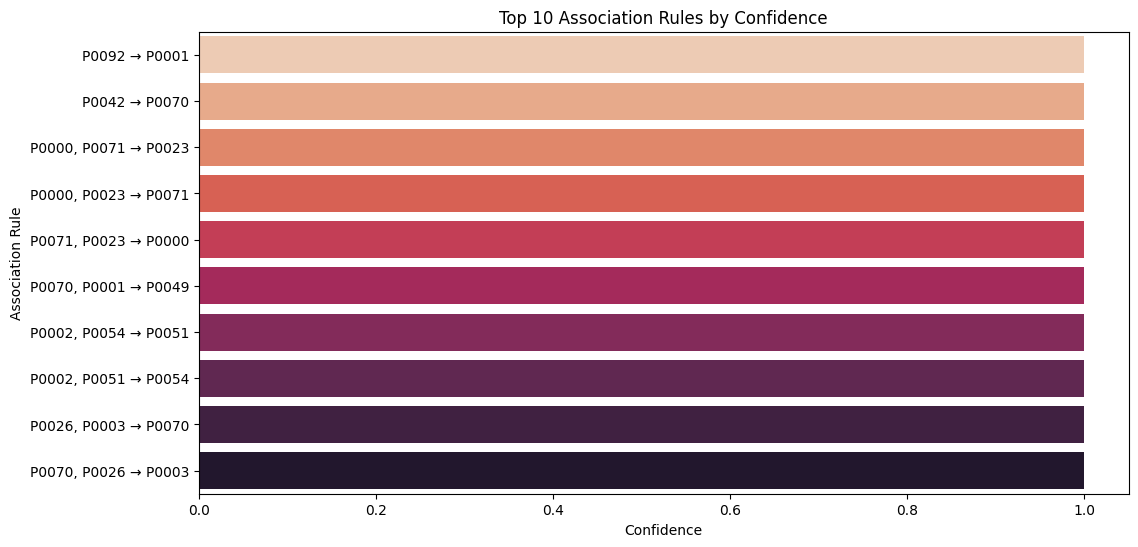

In [ ]:
plot_top_rules(rules, metric='confidence', top_n=10)  # Top 10 by Confidence

This shows up that the most confident rules had a confidence of 100%. That means that every time the antecedent is purchased, the consequence is also purchased. Let's see how frequent each confidence value is.

In [ ]:
# Group rules by confidence and count the number of rules for each confidence value
confidence_counts = rules.groupby('confidence').size().reset_index(name='count')

# Print the number of association rules for each confidence value
print(confidence_counts)


    confidence  count
0     0.500000    113
1     0.538462      2
2     0.555556      2
3     0.571429     32
4     0.583333      1
5     0.600000     74
6     0.625000      4
7     0.666667      8
8     0.714286      4
9     0.750000    102
10    0.800000      6
11    1.000000    179


Now let's evaluate based on support.

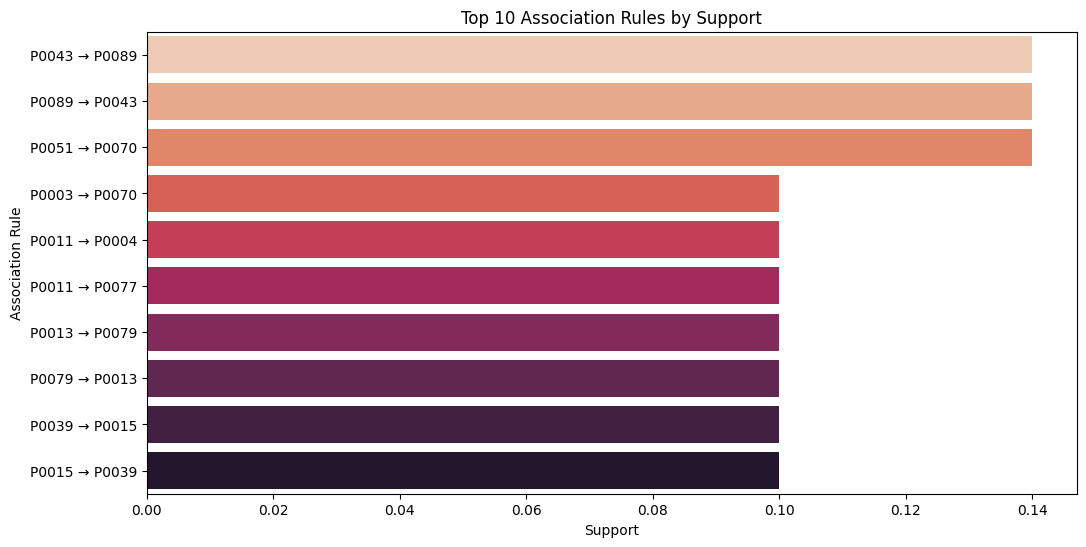

In [ ]:
plot_top_rules(rules, metric='support', top_n=10)     # Top 10 by Support

This shows us that the strongest rules have support between 10-14%, which is coherent with the values we got in the most frequent itemsets containing at least 2 items.

Now let's see for the lift metric.

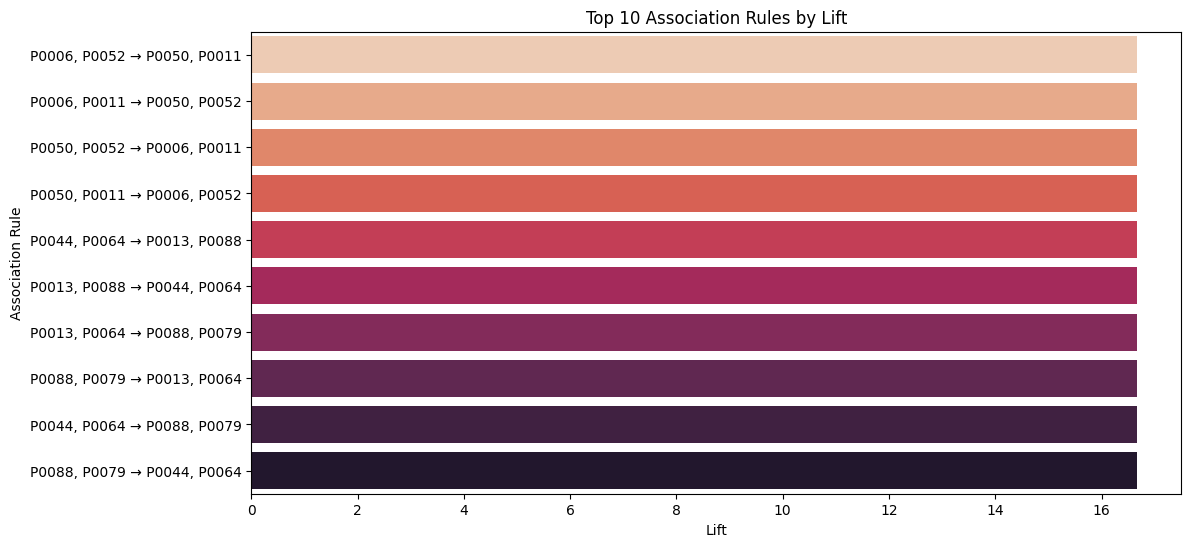

In [ ]:
plot_top_rules(rules, metric='lift', top_n=10)        # Top 10 by Lift

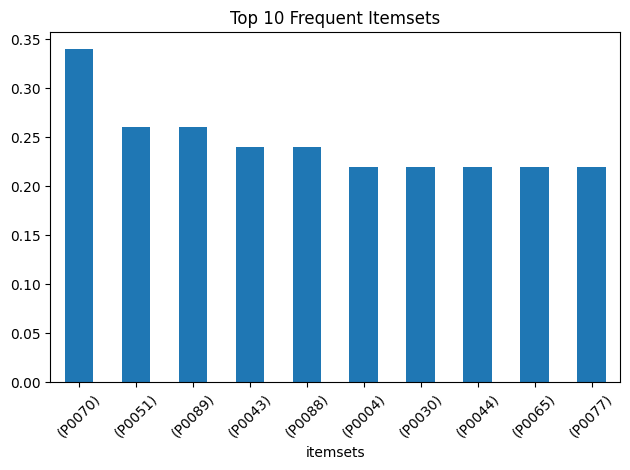

In [ ]:
# Frequent itemsets bar chart
frequent_itemsets.nlargest(10, 'support').plot(kind='bar', x='itemsets', y='support', legend=False)
plt.title('Top 10 Frequent Itemsets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

the strongest association rules had values around 17%. This means that the presence of the antecedent items significantly increases the likelihood of purchasing the consequent items compared to random chance. For example, the rule {P0052, P0050} → {P0011, P0006} with a lift of 17% indicates that customers who purchase P0052 and P0050 together are 17% more likely to also purchase P0011 and P0006 than if these items were bought independently.
